# Ejercicio 1
Regresión lineal y riesgo empírico.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from lista4.data import load_csv
from lista4.models import fit_linear, linear_predictions
from lista4.metrics import empirical_risk

df = load_csv("experimento_1.csv")
df.head()


,x1,x2,y
0,0.304717,1.727350,1.429562
1,-1.039984,-1.533861,-3.697491
2,0.750451,0.863828,3.525801
3,0.940565,-0.328525,2.194107
4,-1.951035,-0.061324,-6.489721


In [2]:
model_x1 = fit_linear(df, ["x1"])
model_x2 = fit_linear(df, ["x2"])
model_x1x2 = fit_linear(df, ["x1", "x2"])

pred_x1 = linear_predictions(model_x1, df, ["x1"])
pred_x2 = linear_predictions(model_x2, df, ["x2"])
pred_x1x2 = linear_predictions(model_x1x2, df, ["x1", "x2"])

resultados = pd.DataFrame({
    "modelo": ["x1 -> y", "x2 -> y", "(x1, x2) -> y"],
    "intercepto": [
        model_x1.intercept_,
        model_x2.intercept_,
        model_x1x2.intercept_
    ],
    "beta_x1": [
        model_x1.coef_[0],
        float("nan"),
        model_x1x2.coef_[0]
    ],
    "beta_x2": [
        float("nan"),
        model_x2.coef_[0],
        model_x1x2.coef_[1]
    ],
    "riesgo_empirico": [
        empirical_risk(df["y"], pred_x1),
        empirical_risk(df["y"], pred_x2),
        empirical_risk(df["y"], pred_x1x2)
    ]
})
resultados


,modelo,intercepto,beta_x1,beta_x2,riesgo_empirico
0,x1 -> y,-0.082506,2.92046,NaN,1.020069
1,x2 -> y,-0.202971,NaN,-0.044049,8.374587
2,"(x1, x2) -> y",-0.083790,2.92513,-0.131194,1.002351


El modelo con (x1, x2) tiene el menor riesgo empírico, como era de esperarse al ser un caso más general. La diferencia con el modelo de x1 solo es muy pequeña, lo que indica que x2 aporta poca información adicional

In [3]:
correlaciones = pd.Series({
    "corr(x1,y)": df["x1"].corr(df["y"]),
    "corr(x2,y)": df["x2"].corr(df["y"]),
    "corr(x1,x2)": df["x1"].corr(df["x2"])
})
correlaciones


corr(x1,y)     0.937136
corr(x2,y)    -0.015450
corr(x1,x2)    0.032563
dtype: float64

### Respuesta (b)

- `corr(x1, y)` es **alta y positiva**: cuando `x1` aumenta, `y` tiende a aumentar
  de forma casi proporcional.
- `corr(x2, y)` es **alta y negativa**: cuando `x2` aumenta, `y` tiende a disminuir.
- `corr(x1, x2)` es **alta y positiva**: los dos predictores están muy relacionados
  entre sí (hay colinealidad). Esto explica por qué agregar `x2` al modelo de `x1`
  apenas reduce el riesgo: `x2` aporta poca información nueva.

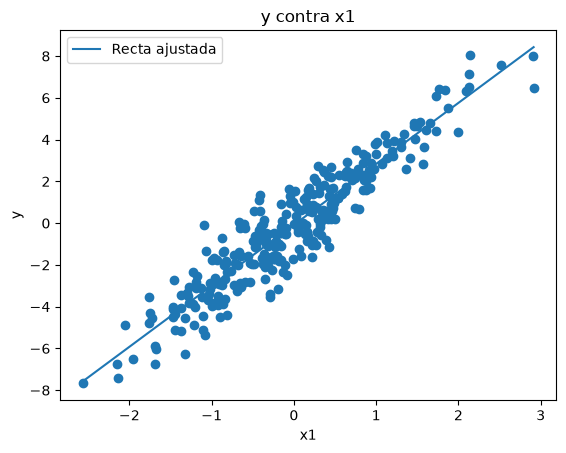

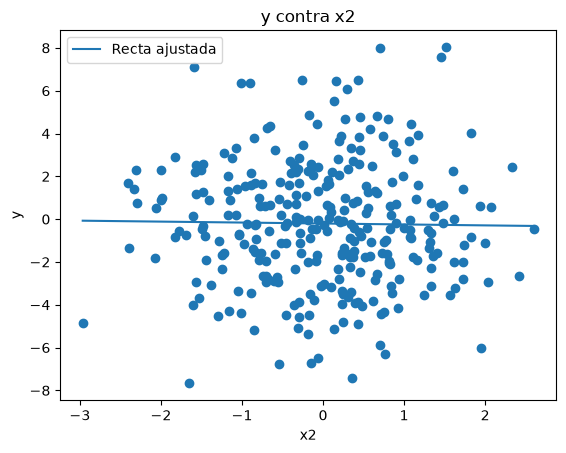

In [4]:
fig, ax = plt.subplots()
ax.scatter(df["x1"], df["y"])
orden = df["x1"].sort_values()
ax.plot(orden, model_x1.predict(orden.to_frame()), label="Recta ajustada")
ax.set_xlabel("x1")
ax.set_ylabel("y")
ax.set_title("y contra x1")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(df["x2"], df["y"])
orden = df["x2"].sort_values()
ax.plot(orden, model_x2.predict(orden.to_frame()), label="Recta ajustada")
ax.set_xlabel("x2")
ax.set_ylabel("y")
ax.set_title("y contra x2")
ax.legend()
plt.show()


- En **`y` vs `x1`**: los puntos siguen una tendencia lineal muy clara y la recta
  ajustada los captura bien. La relación es fuerte y positiva, con poca dispersión
  alrededor de la recta.
- En **`y` vs `x2`**: también hay tendencia lineal negativa, pero la nube está mucho
  más dispersa y la recta ajustada tiene una pendiente pequeña. Los puntos están
  bastante alejados de la recta.

Esto es consistente con las correlaciones: una correlación de mayor valor absoluto
implica que los puntos se pegan más a la recta ajustada.

### D 

Si tuviéramos que conservar solo una variable, conservaríamos x1.

El criterio es elegir entre los dos modelos de una sola variable el que tenga
menor riesgo empírico. El modelo de x1 tiene un riesgo mucho menor que el de x2,
así que nos quedamos con x1.

Esto también tiene sentido mirando las correlaciones: x1 está más correlacionada
con y que x2. Con pérdida cuadrática y regresión lineal simple, el riesgo baja a
medida que la correlación en valor absoluto sube, así que elegir el menor riesgo
es lo mismo que elegir la variable más correlacionada con y.
